In [ ]:
# Approximating fuel load
# GOAL
#   For each lap (raceId, driverId, lap) produce:
#       FuelLoadProxy = 1 - lap / TotalLapsInRace
#   Optional physical estimate in kg:
#       FuelMassEstimate = F_init_kg * FuelLoadProxy
#
# WHY THIS MATTERS
#   Fuel load ≈ car mass component. As fuel burns (proxy ↓),
#   the car gets lighter → potential pace gain → lap time ↓.
#
# ASSUMPTIONS
#   1) Fuel burn per lap is ~linear → proxy linear in lap number.
#   2) TotalLapsInRace is taken from results.laps (max per race),
#      and if missing, from lap_times.lap (max per race).
#   3) Initial fuel mass (F_init_kg) defaults to 110 kg (modern era),

import os
import pandas as pd

# === 0) Point this to your dataset folder ===
#DATA_DIR = r"/path/to/formula-1-world-championship-1950-2020"


# 1) Unzip into /content/Project (overwrite if it exists)
!mkdir -p /content/Project
!unzip -o /content/Project.zip -d /content/Project > /dev/null

# 2) (Recommended) Auto-detect the actual folder that contains the CSVs
#    (Sometimes the zip has a nested folder like 'formula-1-world-championship-1950-2020')
import os

def find_data_dir(root="/content/Project"):
    required = {"races.csv", "results.csv", "lap_times.csv"}
    for current_root, dirs, files in os.walk(root):
        files_lower = {f.lower() for f in files}
        # match case-insensitively
        if {"races.csv", "results.csv", "lap_times.csv"}.issubset(files_lower):
            return current_root
    return None

DATA_DIR = find_data_dir()
print("DATA_DIR =", DATA_DIR)

# 3) Sanity check: list files
if DATA_DIR:
    print("Found files in DATA_DIR:")
    print(sorted(os.listdir(DATA_DIR))[:20])
else:
    print("Could not find the CSVs. Check the zip contents or path.")



# Helper to read CSV with graceful errors + show columns
def read_csv_safely(fname):
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path, low_memory=False)
    print(f"\nLoaded {fname} → shape={df.shape}")
    print("Columns:", list(df.columns))
    return df

# 1) Load the core tables we need
races       = read_csv_safely("races.csv")        # raceId, year, round, circuitId, date, time, name, ...
results     = read_csv_safely("results.csv")      # resultId, raceId, driverId, constructorId, grid, position, laps, ...
lap_times   = read_csv_safely("lap_times.csv")    # raceId, driverId, lap, position, time, milliseconds
# (Others you might load later: pit_stops.csv, drivers.csv, circuits.csv, etc.)

# 2) Light column sanity (datasets sometimes evolve across mirrors)
#    Standard names we rely on here:
expected_races_cols    = {"raceId", "year", "round", "circuitId", "name", "date"}
expected_results_cols  = {"raceId", "driverId", "laps"}
expected_laptime_cols  = {"raceId", "driverId", "lap"}

missing_races  = expected_races_cols   - set(races.columns)
missing_result = expected_results_cols - set(results.columns)
missing_laps   = expected_laptime_cols - set(lap_times.columns)

if missing_races:
    print("WARNING: races.csv missing columns:", missing_races)
if missing_result:
    print("WARNING: results.csv missing columns:", missing_result)
if missing_laps:
    print("WARNING: lap_times.csv missing columns:", missing_laps)

# 3) Compute TotalLapsInRace
#    Prefer results.laps (max completed by any classified driver),
#    because lap_times might be absent for some legacy years.
total_laps_from_results = (
    results
    .groupby("raceId", as_index=False)["laps"]
    .max()
    .rename(columns={"laps": "TotalLapsInRace_results"})
)

total_laps_from_laptimes = (
    lap_times
    .groupby("raceId", as_index=False)["lap"]
    .max()
    .rename(columns={"lap": "TotalLapsInRace_laptimes"})
)

# Merge both sources; choose results first, fallback to lap_times
total_laps = pd.merge(total_laps_from_results,
                      total_laps_from_laptimes,
                      on="raceId",
                      how="outer")

def choose_total_laps(row):
    # Prefer results-based total; if NaN, fallback to lap_times-based
    if pd.notna(row.get("TotalLapsInRace_results")):
        return int(row["TotalLapsInRace_results"])
    if pd.notna(row.get("TotalLapsInRace_laptimes")):
        return int(row["TotalLapsInRace_laptimes"])
    return pd.NA  # in very old/odd cases

total_laps["TotalLapsInRace"] = total_laps.apply(choose_total_laps, axis=1)
total_laps = total_laps[["raceId", "TotalLapsInRace"]]

print("\nSample of TotalLapsInRace:")
print(total_laps.head())

# 4) Attach TotalLapsInRace to lap_times
lap_df = pd.merge(lap_times, total_laps, on="raceId", how="left")

# Sanity: drop rows with missing total laps (rare; could also filter to years w/ full timing)
missing_total = lap_df["TotalLapsInRace"].isna().sum()
if missing_total > 0:
    print(f"NOTE: {missing_total} lap rows lack TotalLapsInRace. Dropping them.")
    lap_df = lap_df.dropna(subset=["TotalLapsInRace"])

# 5) Compute FuelLoadProxy = 1 - lap / TotalLapsInRace
#    Keep it float and clipped to [0, 1] just in case of odd data.
lap_df["FuelLoadProxy"] = 1.0 - (lap_df["lap"].astype(float) / lap_df["TotalLapsInRace"].astype(float))
lap_df["FuelLoadProxy"] = lap_df["FuelLoadProxy"].clip(lower=0.0, upper=1.0)

# 6) Optional: Physical mass estimate (assume 110 kg initial fuel; tweak per era/track later)
F_init_kg = 110.0
lap_df["FuelMassEstimate_kg"] = F_init_kg * lap_df["FuelLoadProxy"]

# 7) Keep only the minimal columns you’ll feed to your model merge later
out_cols = [
    "raceId", "driverId", "lap",
    "FuelLoadProxy", "FuelMassEstimate_kg",
    "TotalLapsInRace"
]
fuel_feature = lap_df[out_cols].copy()

print("\nFuel feature preview:")
print(fuel_feature.head(10))

# 8) Save for later joins with your modeling table (lap_times merged with features)
OUT_PATH = os.path.join(DATA_DIR, "features_fuel_load_proxy.csv")
fuel_feature.to_csv(OUT_PATH, index=False)
print(f"\nSaved fuel-load features → {OUT_PATH}")



DATA_DIR = /content/Project/Project
Found files in DATA_DIR:
['LoadingData.ipynb', 'circuits.csv', 'constructor_results.csv', 'constructor_standings.csv', 'constructors.csv', 'driver_standings.csv', 'drivers.csv', 'lap_times.csv', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv']

Loaded races.csv → shape=(1125, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']

Loaded results.csv → shape=(26759, 18)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

Loaded lap_times.csv → shape=(589081, 6)
Columns: ['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']

Sample of To

In [ ]:
# ------------------------------------------------------------
# Derive "#laps done before each pit stop" feature (CLEANED)
# ------------------------------------------------------------
# INPUTS:
#   pit_stops.csv (raceId, driverId, stop, lap, time, duration, etc.)
#   results.csv   (for sanity-check total laps if needed)
# OUTPUT:
#   DataFrame with:
#       raceId, driverId, stop, lap (of pit), LapsBeforePit
# ------------------------------------------------------------

import os
import pandas as pd

# Assume DATA_DIR already set from earlier step
def read_csv_safely(fname):
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path, low_memory=False)
    print(f"\nLoaded {fname} → shape={df.shape}")
    print("Columns:", list(df.columns))
    return df

# 1) Load the pit_stops table
pit_stops = read_csv_safely("pit_stops.csv")

# Expected columns sanity-check
expected_cols = {"raceId", "driverId", "stop", "lap"}
missing = expected_cols - set(pit_stops.columns)
if missing:
    print(" WARNING: Missing columns in pit_stops.csv:", missing)

# 2) Convert 'stop' and 'lap' to numeric
pit_stops["stop"] = pd.to_numeric(pit_stops["stop"], errors="coerce")
pit_stops["lap"]  = pd.to_numeric(pit_stops["lap"],  errors="coerce")

# Drop rows with missing numeric fields
pit_stops = pit_stops.dropna(subset=["raceId", "driverId", "lap", "stop"])

# ------------------------------------------------------------
# **CRITICAL FIX**
# F1 cars never have 15, 42, 70 pit stops.
# The dataset sometimes includes corrupted 'stop' values.
# We remove stops outside 1–4 (safe for all modern F1 seasons).
# ------------------------------------------------------------
pit_stops = pit_stops[pit_stops["stop"].between(1, 4)]

# 3) Proper ordering for diff computation
pit_stops = pit_stops.sort_values(["raceId", "driverId", "stop"]).reset_index(drop=True)

# 4) Compute laps done before each pit stop
def compute_laps_before(group):
    group = group.sort_values("stop").copy()

    # Δlap between stops
    group["LapsBeforePit"] = group["lap"].diff().fillna(group["lap"].iloc[0] - 1)

    # Avoid negative (if pit on lap 1)
    group["LapsBeforePit"] = group["LapsBeforePit"].clip(lower=0)
    return group

pit_with_laps = (
    pit_stops
    .groupby(["raceId", "driverId"], group_keys=False)
    .apply(compute_laps_before)
)

# 5) Keep clean subset
pit_feature = pit_with_laps[["raceId", "driverId", "stop", "lap", "LapsBeforePit"]].copy()

print("\n Derived 'laps done before each pit stop' preview:")
print(pit_feature.head(10))

# 6) Optional sanity check: average stint length per stop number
avg_stint = (
    pit_feature.groupby("stop")["LapsBeforePit"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

print("\nAverage laps before each pit number:")
print(avg_stint)

# 7) Save cleaned version
OUT_PATH = os.path.join(DATA_DIR, "features_laps_before_pit.csv")
pit_feature.to_csv(OUT_PATH, index=False)
print(f"\nSaved → {OUT_PATH}")




Loaded pit_stops.csv → shape=(11371, 7)
Columns: ['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']

 Derived 'laps done before each pit stop' preview:
   raceId  driverId  stop  lap  LapsBeforePit
0     841         1     1   16           15.0
1     841         1     2   36           20.0
2     841         2     1   15           14.0
3     841         2     2   30           15.0
4     841         3     1   16           15.0
5     841         4     1   12           11.0
6     841         4     2   27           15.0
7     841         4     3   42           15.0
8     841         5     1   17           16.0
9     841        10     1   18           17.0

Average laps before each pit number:
   stop  AvgLapsBeforePit
0     1             15.39
1     2             18.15
2     3             14.53
3     4             13.21

Saved → /content/Project/Project/features_laps_before_pit.csv


/tmp/ipython-input-2454834174.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_laps_before)


In [ ]:
# ------------------------------------------------------------
# Derive:
#   1. Number of pit stops per race per driver
#   2. Driver standing in previous race
# ------------------------------------------------------------
# INPUTS:
#   pit_stops.csv
#   results.csv
#   races.csv
#   driver_standings.csv  (if available, else fallback to results)
#
# OUTPUTS:
#   features_num_pitstops.csv
#   features_prev_race_standing.csv
# ------------------------------------------------------------

import os
import pandas as pd

def read_csv_safely(fname):
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path, low_memory=False)
    print(f"\nLoaded {fname} → shape={df.shape}")
    print("Columns:", list(df.columns))
    return df

# === 1) Load required tables ===
pit_stops  = read_csv_safely("pit_stops.csv")
races      = read_csv_safely("races.csv")
results    = read_csv_safely("results.csv")

# Some Kaggle mirrors also have "driver_standings.csv"
standings_path = os.path.join(DATA_DIR, "driver_standings.csv")
has_driver_standings = os.path.exists(standings_path)
if has_driver_standings:
    driver_standings = read_csv_safely("driver_standings.csv")

# ------------------------------------------------------------
# (A) NUMBER OF PIT STOPS
# ------------------------------------------------------------
expected_cols = {"raceId", "driverId"}
missing = expected_cols - set(pit_stops.columns)
if missing:
    print("⚠️ Missing columns in pit_stops.csv:", missing)

# Apply the 1-4 pit stop filter before counting
pit_stops_cleaned = pit_stops[pit_stops["stop"].between(1, 4)].copy()

# Count stops per driver per race
num_pitstops = (
    pit_stops_cleaned.groupby(["raceId", "driverId"], as_index=False)["stop"]
    .count()
    .rename(columns={"stop": "NumPitStops"})
)

print("\n Sample of NumPitStops per race/driver:")
print(num_pitstops.head(10))

# Save
OUT_PATH_PIT = os.path.join(DATA_DIR, "features_num_pitstops.csv")
num_pitstops.to_csv(OUT_PATH_PIT, index=False)
print(f"Saved → {OUT_PATH_PIT}")

# ------------------------------------------------------------
# (B) DRIVER STANDING IN PREVIOUS RACE
# ------------------------------------------------------------

# --- Step 1: get race sequence (year + round)
races_small = races[["raceId", "year", "round"]].copy()

# Merge race metadata to results (so we know which year & round each result belongs to)
results_ext = pd.merge(results, races_small, on="raceId", how="left")

# --- Step 2: choose which table to use for standings ---
if has_driver_standings:
    # Use official driver_standings.csv if available
    # It contains: driverStandingsId, raceId, driverId, points, position, wins
    standings = pd.merge(driver_standings, races_small, on="raceId", how="left")
    standings = standings[["driverId", "year", "round", "position"]].copy()
    standings.rename(columns={"position": "Standing"}, inplace=True)
else:
    # Fallback: use final race result position as standing proxy
    standings = results_ext[["driverId", "year", "round", "positionOrder"]].copy()
    standings.rename(columns={"positionOrder": "Standing"}, inplace=True)

# Convert to numeric
standings["Standing"] = pd.to_numeric(standings["Standing"], errors="coerce")

# --- Step 3: shift standings by one race per driver per season ---
# Sort to ensure correct ordering
standings = standings.sort_values(["driverId", "year", "round"]).reset_index(drop=True)

# Compute standing in previous round
standings["PrevRaceStanding"] = standings.groupby(["driverId", "year"])["Standing"].shift(1)

# Drop first rounds (since they have no previous)
standings = standings.dropna(subset=["PrevRaceStanding"])

# --- Step 4: Join raceId info to map the "current race" with its previous standing ---
# We need to reattach raceId for the current race (round)
standings_with_raceId = pd.merge(
    standings,
    races_small,
    on=["year", "round"],
    how="left"
)[["raceId", "driverId", "PrevRaceStanding"]]

print("\n Sample of PrevRaceStanding per race/driver:")
print(standings_with_raceId.head(10))

# Save
OUT_PATH_STAND = os.path.join(DATA_DIR, "features_prev_race_standing.csv")
standings_with_raceId.to_csv(OUT_PATH_STAND, index=False)
print(f"Saved → {OUT_PATH_STAND}")

# ------------------------------------------------------------
# Done — two new feature tables are now ready:
#   - features_num_pitstops.csv          → per race/driver
#   - features_prev_race_standing.csv    → per race/driver
# ------------------------------------------------------------



Loaded pit_stops.csv → shape=(11371, 7)
Columns: ['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']

Loaded races.csv → shape=(1125, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']

Loaded results.csv → shape=(26759, 18)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

Loaded driver_standings.csv → shape=(34863, 7)
Columns: ['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']

 Sample of NumPitStops per race/driver:
   raceId  driverId  NumPitStops
0     841         1            2
1     841         2            2
2     841         3            1
3     841         4            


📈 Correlation matrix:

                  NumPitStops  AvgLapsBeforePit  PrevRaceStanding  \
NumPitStops             1.000            -0.523             0.042   
AvgLapsBeforePit       -0.523             1.000            -0.039   
PrevRaceStanding        0.042            -0.039             1.000   
FuelLoadProxy          -0.011            -0.016             0.019   

                  FuelLoadProxy  
NumPitStops              -0.011  
AvgLapsBeforePit         -0.016  
PrevRaceStanding          0.019  
FuelLoadProxy             1.000  


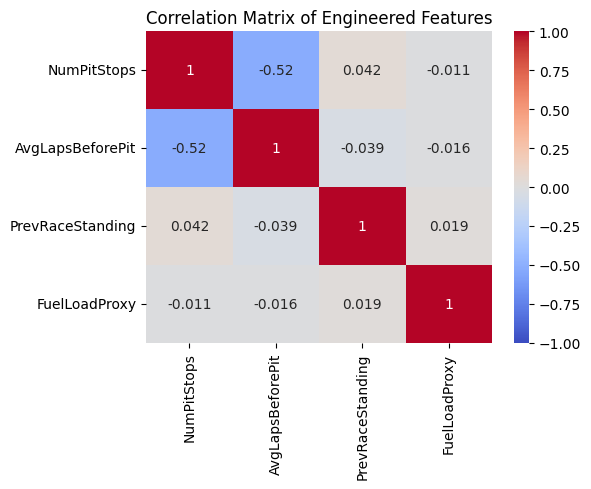

In [ ]:
# ------------------------------------------------------------
# CORRELATION MATRIX of Engineered Features
# ------------------------------------------------------------
# Features:
#   - NumPitStops
#   - LapsBeforePit
#   - PrevRaceStanding
#   - FuelLoadProxy
# ------------------------------------------------------------

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load feature tables ===
fuel      = pd.read_csv(os.path.join(DATA_DIR, "features_fuel_load_proxy.csv"))
laps_pit  = pd.read_csv(os.path.join(DATA_DIR, "features_laps_before_pit.csv"))
num_pit   = pd.read_csv(os.path.join(DATA_DIR, "features_num_pitstops.csv"))
prev_st   = pd.read_csv(os.path.join(DATA_DIR, "features_prev_race_standing.csv"))

# === Merge them on raceId & driverId (lap if applicable) ===
# LapsBeforePit is per pit stop, not per lap, so you might want a simplified merge at race/driver level.
# For simplicity, aggregate LapsBeforePit as mean per race-driver (average stint length).
laps_avg = (
    laps_pit.groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# Merge all into one DataFrame (only matching races/drivers)
df_features = (
    fuel.merge(num_pit, on=["raceId", "driverId"], how="inner")
         .merge(laps_avg, on=["raceId", "driverId"], how="left")
         .merge(prev_st, on=["raceId", "driverId"], how="left")
)

# Keep only numeric columns we care about
cols_of_interest = ["NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding", "FuelLoadProxy"]
corr_df = df_features[cols_of_interest].copy()

# === Compute correlation matrix ===
corr_matrix = corr_df.corr(method="pearson")   # Pearson correlation (default)
print("\n📈 Correlation matrix:\n")
print(corr_matrix.round(3))

# === Visualize with heatmap ===
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()



📈 Correlation matrix:

                  NumPitStops  AvgLapsBeforePit  PrevRaceStanding  \
NumPitStops             1.000            -0.523             0.042   
AvgLapsBeforePit       -0.523             1.000            -0.039   
PrevRaceStanding        0.042            -0.039             1.000   
FuelLoadProxy          -0.011            -0.016             0.019   

                  FuelLoadProxy  
NumPitStops              -0.011  
AvgLapsBeforePit         -0.016  
PrevRaceStanding          0.019  
FuelLoadProxy             1.000  


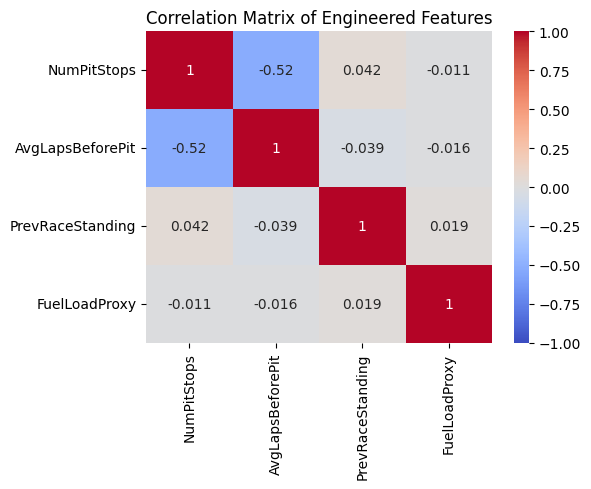

In [ ]:
# ------------------------------------------------------------
# CORRELATION MATRIX of Engineered Features
# ------------------------------------------------------------
# Features:
#   - NumPitStops
#   - LapsBeforePit
#   - PrevRaceStanding
#   - FuelLoadProxy
# ------------------------------------------------------------

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load feature tables ===
fuel      = pd.read_csv(os.path.join(DATA_DIR, "features_fuel_load_proxy.csv"))
laps_pit  = pd.read_csv(os.path.join(DATA_DIR, "features_laps_before_pit.csv"))
num_pit   = pd.read_csv(os.path.join(DATA_DIR, "features_num_pitstops.csv"))
prev_st   = pd.read_csv(os.path.join(DATA_DIR, "features_prev_race_standing.csv"))

# === Merge them on raceId & driverId (lap if applicable) ===
# LapsBeforePit is per pit stop, not per lap, so you might want a simplified merge at race/driver level.
# For simplicity, aggregate LapsBeforePit as mean per race-driver (average stint length).
laps_avg = (
    laps_pit.groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# Merge all into one DataFrame (only matching races/drivers)
df_features = (
    fuel.merge(num_pit, on=["raceId", "driverId"], how="inner")
         .merge(laps_avg, on=["raceId", "driverId"], how="left")
         .merge(prev_st, on=["raceId", "driverId"], how="left")
)

# Keep only numeric columns we care about
cols_of_interest = ["NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding", "FuelLoadProxy"]
corr_df = df_features[cols_of_interest].copy()

# === Compute correlation matrix ===
corr_matrix = corr_df.corr(method="pearson")   # Pearson correlation (default)
print("\n📈 Correlation matrix:\n")
print(corr_matrix.round(3))

# === Visualize with heatmap ===
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()


📈 Correlation matrix (including LapTime_sec):

                  LapTime_sec  NumPitStops  AvgLapsBeforePit  \
LapTime_sec             1.000        0.046            -0.067   
NumPitStops             0.046        1.000            -0.536   
AvgLapsBeforePit       -0.067       -0.536             1.000   
PrevRaceStanding        0.012        0.043            -0.036   
FuelLoadProxy           0.000       -0.004            -0.005   

                  PrevRaceStanding  FuelLoadProxy  
LapTime_sec                  0.012          0.000  
NumPitStops                  0.043         -0.004  
AvgLapsBeforePit            -0.036         -0.005  
PrevRaceStanding             1.000          0.016  
FuelLoadProxy                0.016          1.000  


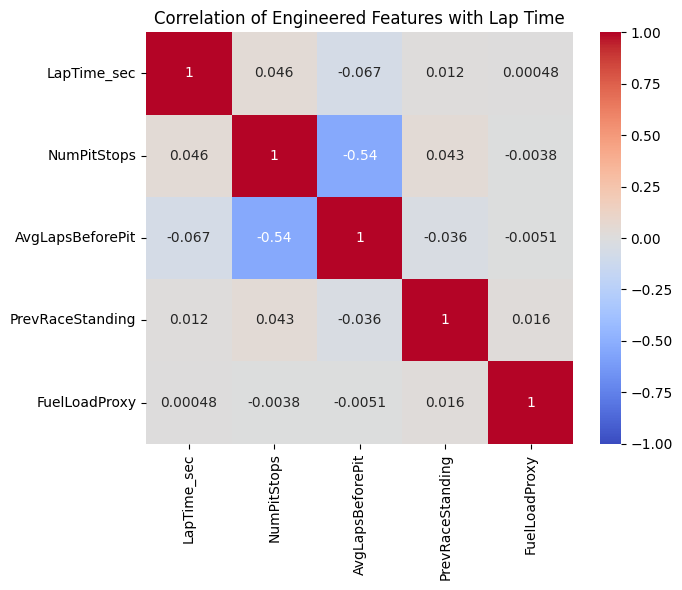

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load feature tables ===
fuel      = pd.read_csv(os.path.join(DATA_DIR, "features_fuel_load_proxy.csv"))
laps_pit  = pd.read_csv(os.path.join(DATA_DIR, "features_laps_before_pit.csv"))
num_pit   = pd.read_csv(os.path.join(DATA_DIR, "features_num_pitstops.csv"))
prev_st   = pd.read_csv(os.path.join(DATA_DIR, "features_prev_race_standing.csv"))

# Fix: Load original lap_times.csv and process it
lap_times = pd.read_csv(os.path.join(DATA_DIR, "lap_times.csv"))
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()

# === Prepare lap times (keep only needed columns) ===
lap_times = lap_times[["raceId", "driverId", "lap", "LapTime_sec"]]

# === Aggregate laps-before-pit feature ===
laps_avg = (
    laps_pit.groupby(["raceId", "driverId"], as_index=False)["LapsBeforePit"]
            .mean()
            .rename(columns={"LapsBeforePit": "AvgLapsBeforePit"})
)

# === Merge all engineered features ===
df_features = (
    fuel.merge(num_pit, on=["raceId", "driverId"], how="inner")
         .merge(laps_avg, on=["raceId", "driverId"], how="left")
         .merge(prev_st, on=["raceId", "driverId"], how="left")
)

# === Merge lap times with engineered features (per lap) ===
df = lap_times.merge(df_features, on=["raceId", "driverId"], how="inner")

# === Select columns of interest for correlation ===
cols_of_interest = [
    "LapTime_sec",        # <--- TARGET ADDED
    "NumPitStops",
    "AvgLapsBeforePit",
    "PrevRaceStanding",
    "FuelLoadProxy",
]

corr_df = df[cols_of_interest].copy()

# === Compute correlation ===
corr_matrix = corr_df.corr(method="pearson")

print("\n📈 Correlation matrix (including LapTime_sec):\n")
print(corr_matrix.round(3))

# === Visualize ===
plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Engineered Features with Lap Time")
plt.tight_layout()
plt.show()

In [ ]:
import os, numpy as np, pandas as pd
from sklearn.feature_extraction import FeatureHasher

# --- Helper functions (redefined for cell execution independence) ---
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    for root in ("/content", "/content/Project", "/content/drive/MyDrive"):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                # print(f"✓ Found {filename} \u2192 {p}") # Suppress verbose output
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# --- Load lap times and initial features to recreate 'df' ---
lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

fuel     = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit = load_csv_anywhere("features_laps_before_pit.csv")
num_pit  = load_csv_anywhere("features_num_pitstops.csv")
prev_st  = load_csv_anywhere("features_prev_race_standing.csv")
races    = load_csv_anywhere("races.csv")
races = races[races['year'] >= 2010].copy() # Filter as in previous step

results  = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()
pit_stops_orig = load_csv_anywhere("pit_stops.csv") # Original pit stops for LapsSincePit

# Apply the 1-4 pit stop filter before using pit_stops_orig for LapsSincePit calculation
pit_stops_for_laps_since_pit = pit_stops_orig[pit_stops_orig["stop"].between(1, 4)].copy()

# Average laps-before-pit per race-driver
laps_avg = (
laps_pit.groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
.mean().rename(columns={"LapsBeforePit":"AvgLapsBeforePit"}))

# --- Merge everything to create the base df ---
df_recreated = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# --- Clean + filter outliers ---
df_recreated = df_recreated.dropna(subset=["LapTime_sec","FuelLoadProxy","NumPitStops",
                       "AvgLapsBeforePit","PrevRaceStanding","circuitId",
                       "driverId","constructorId"])
df_recreated = df_recreated[df_recreated["LapTime_sec"] < 200]
df_recreated = df_recreated[df_recreated["LapTime_sec"] > 60]
df_recreated = df_recreated.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# --- Create LapsSincePit and LapsSincePitSquared ---
pit_laps = (
    pit_stops_for_laps_since_pit.groupby(["raceId", "driverId"])[["lap"]]
    .apply(lambda x: sorted(x["lap"].unique().tolist()))
    .to_dict()
)

def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df_recreated["LapsSincePit"] = df_recreated.apply(laps_since_last_pit, axis=1)
df_recreated["LapsSincePitSquared"] = df_recreated["LapsSincePit"] ** 2

# --- Incorporate PitStopDuration_sec ---
pit_stops_df = pit_stops_orig # Already loaded as pit_stops_orig
pit_stops_df = pit_stops_df[pit_stops_df["stop"].between(1, 4)].copy()
pit_stops_df["PitStopDuration_sec"] = pd.to_numeric(pit_stops_df["duration"], errors="coerce")
missing_duration_mask = pit_stops_df["PitStopDuration_sec"].isna()
pit_stops_df.loc[missing_duration_mask, "PitStopDuration_sec"] = (
    pd.to_numeric(pit_stops_df.loc[missing_duration_mask, "milliseconds"], errors="coerce") / 1000.0
)
pit_stops_df = pit_stops_df.dropna(subset=["PitStopDuration_sec"])
pit_duration_feature = pit_stops_df[["raceId", "driverId", "lap", "PitStopDuration_sec"]].copy()
df_recreated = pd.merge(df_recreated, pit_duration_feature, on=["raceId", "driverId", "lap"], how="left")
df_recreated["PitStopDuration_sec"] = df_recreated["PitStopDuration_sec"].fillna(0)

# --- Create the driver-circuit interaction feature string ---
df_with_interaction = df_recreated.copy()
df_with_interaction['driver_circuit_interaction'] = df_with_interaction['driverId'].astype(str) + '_' + df_with_interaction['circuitId'].astype(str)

# --- Apply Feature Hashing to 'driver_circuit_interaction' ---
n_hashed_features = 2**10 # Example: 1024 new features for the interaction
hasher = FeatureHasher(n_features=n_hashed_features, input_type='string')
hashed_interaction_features = hasher.fit_transform(df_with_interaction['driver_circuit_interaction'].apply(lambda x: [x]))
hashed_df = pd.DataFrame(hashed_interaction_features.toarray(), index=df_with_interaction.index)
hashed_df.columns = [f'driver_circuit_hash_{i}' for i in range(n_hashed_features)]

# --- One-hot encode other categorical columns ---
for col in ["circuitId","driverId","constructorId"]:
    df_with_interaction[col] = df_with_interaction[col].astype(str)
df_encoded_base = pd.get_dummies(df_with_interaction,
                                 columns=["circuitId","driverId","constructorId"],
                                 drop_first=True)

# --- Combine base features, other one-hot encoded features, and hashed interaction features ---
base_features = [
    "NumPitStops",
    "AvgLapsBeforePit",
    "PrevRaceStanding",
    "FuelLoadProxy",
    "LapsSincePit",
    "LapsSincePitSquared",
    "PitStopDuration_sec"
]

X_combined = df_encoded_base[base_features].copy()
cat_features_no_interaction = [c for c in df_encoded_base.columns
                                 if c.startswith(("circuitId_","driverId_","constructorId_"))]
X_combined = pd.concat([X_combined, df_encoded_base[cat_features_no_interaction]], axis=1)
X_combined = pd.concat([X_combined, hashed_df], axis=1)

y_interaction = pd.to_numeric(df_encoded_base["LapTime_sec"], errors="coerce")
X_combined, y_interaction = X_combined.align(y_interaction, join='inner', axis=0)

mask_interaction = X_combined.notna().all(axis=1) & y_interaction.notna()
X_interaction_final, y_interaction_final = X_combined.loc[mask_interaction].astype(float), y_interaction.loc[mask_interaction].astype(float)


print("\n=== Final Feature Set Overview ===")
print(f"Total number of samples (rows) in X: {X_interaction_final.shape[0]}")
print(f"Total number of input features (columns) in X: {X_interaction_final.shape[1]}")

print("\n--- Breakdown of Feature Types ---")

# Identify numerical features
# Re-use the defined base_features list directly
print(f"Number of base numerical features: {len(base_features)}")
print(f"  - Base numerical features: {base_features}")

# Count one-hot encoded and hashed features
num_circuit_dummies = sum(1 for col in X_interaction_final.columns if col.startswith('circuitId_'))
num_driver_dummies = sum(1 for col in X_interaction_final.columns if col.startswith('driverId_'))
num_constructor_dummies = sum(1 for col in X_interaction_final.columns if col.startswith('constructorId_'))
num_hashed_interaction_features = sum(1 for col in X_interaction_final.columns if col.startswith('driver_circuit_hash_'))

print(f"Number of one-hot encoded circuitId features: {num_circuit_dummies}")
print(f"Number of one-hot encoded driverId features: {num_driver_dummies}")
print(f"Number of one-hot encoded constructorId features: {num_constructor_dummies}")
print(f"Number of hashed driver_circuit_interaction features: {num_hashed_interaction_features}")

# Verify sum matches total
assert (len(base_features) + num_circuit_dummies + num_driver_dummies + num_constructor_dummies + num_hashed_interaction_features) == X_interaction_final.shape[1], "Feature count mismatch!"

print("\n--- Sample of Feature Names ---")
# Print a sample of all feature names, especially the categorical and hashed ones
print(X_interaction_final.columns.tolist()[:10]) # First 10 feature names
print(X_interaction_final.columns.tolist()[-10:]) # Last 10 feature names (likely hashed features)

/tmp/ipython-input-1936152921.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_recreated = df_recreated.groupby("raceId", group_keys=False).apply(



=== Final Feature Set Overview ===
Total number of samples (rows) in X: 295038
Total number of input features (columns) in X: 1159

--- Breakdown of Feature Types ---
Number of base numerical features: 7
  - Base numerical features: ['NumPitStops', 'AvgLapsBeforePit', 'PrevRaceStanding', 'FuelLoadProxy', 'LapsSincePit', 'LapsSincePitSquared', 'PitStopDuration_sec']
Number of one-hot encoded circuitId features: 34
Number of one-hot encoded driverId features: 72
Number of one-hot encoded constructorId features: 22
Number of hashed driver_circuit_interaction features: 1024

--- Sample of Feature Names ---
['NumPitStops', 'AvgLapsBeforePit', 'PrevRaceStanding', 'FuelLoadProxy', 'LapsSincePit', 'LapsSincePitSquared', 'PitStopDuration_sec', 'circuitId_10.0', 'circuitId_11.0', 'circuitId_12.0']
['driver_circuit_hash_1014', 'driver_circuit_hash_1015', 'driver_circuit_hash_1016', 'driver_circuit_hash_1017', 'driver_circuit_hash_1018', 'driver_circuit_hash_1019', 'driver_circuit_hash_1020', 'dr

NumPitStops and AvgLapsBeforePit are strongly negatively correlated → more pit stops → shorter stints.

PrevRaceStanding is weakly correlated → relatively independent feature.

FuelLoadProxy (lap progression proxy) is modestly correlated with strategy variables.


 Average within-driver correlation matrix:

                  NumPitStops  AvgLapsBeforePit  PrevRaceStanding  \
AvgLapsBeforePit       -0.524             1.000             0.024   
FuelLoadProxy          -0.018            -0.019             0.003   
NumPitStops             1.000            -0.524             0.008   
PrevRaceStanding        0.008             0.024             1.000   

                  FuelLoadProxy  
AvgLapsBeforePit         -0.019  
FuelLoadProxy             1.000  
NumPitStops              -0.018  
PrevRaceStanding          0.003  


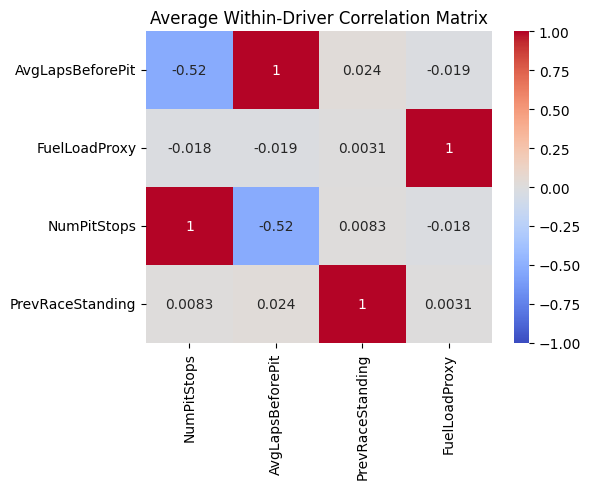

In [ ]:
#Compute per-driver correlation matrices to control for driver bias:
'''When you computed the overall correlation matrix earlier,
it mixed data from all drivers and races together.

That means:
Lewis Hamilton’s laps (fast, low lap times, strategic pit patterns)
Nicolas Latifi’s laps (slower, different strategy)
are both contributing to the same averages.

So your correlations reflect both:
Physical relationships (e.g., fewer laps → higher fuel → slower lap time)
Between-driver effects (e.g., Hamilton’s team just tends to do more pit stops and go faster)
That second effect is driver bias — systematic differences between drivers or teams that aren’t about the underlying physics.'''

# ------------------------------------------------------------
# Per-driver correlation matrices (control for driver bias)
# ------------------------------------------------------------
# Each driver's subset is used to compute a local correlation matrix,
# then we average these matrices across drivers.
# ------------------------------------------------------------

cols = ["NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding", "FuelLoadProxy"]

# Group by driverId and compute correlation matrix for each
corr_by_driver = df_features.groupby("driverId")[cols].corr()

# corr_by_driver is a multi-index (driverId, feature_i, feature_j)
# Let's average across drivers
corr_mean = corr_by_driver.groupby(level=1).mean()

print("\n Average within-driver correlation matrix:\n")
print(corr_mean.round(3))

# Optional visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr_mean, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Average Within-Driver Correlation Matrix")
plt.tight_layout()
plt.show()





📈 Corrected Within-Driver Correlation Matrix (diag = 1):

Feature_j         AvgLapsBeforePit  FuelLoadProxy  LapTime_sec  NumPitStops  \
Feature_i                                                                     
AvgLapsBeforePit             1.000         -0.006       -0.110       -0.549   
FuelLoadProxy               -0.006          1.000       -0.001       -0.007   
LapTime_sec                 -0.110         -0.001        1.000        0.053   
NumPitStops                 -0.549         -0.007        0.053        1.000   
PrevRaceStanding             0.022          0.003        0.012        0.008   

Feature_j         PrevRaceStanding  
Feature_i                           
AvgLapsBeforePit             0.022  
FuelLoadProxy                0.003  
LapTime_sec                  0.012  
NumPitStops                  0.008  
PrevRaceStanding             1.000  


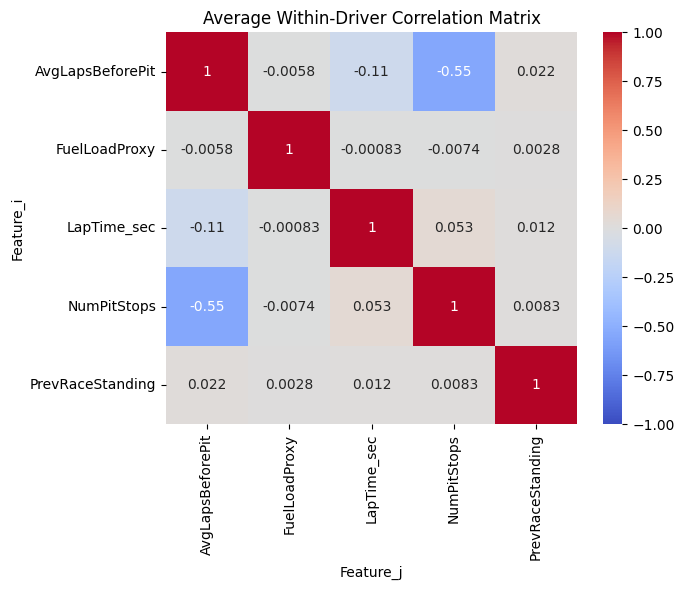

In [ ]:
# ------------------------------------------------------------
# FIXED: Preserve diagonal = 1 in averaged within-driver matrix
# ------------------------------------------------------------

# Ensure 'cols' includes 'LapTime_sec' if it's meant to be in the correlation
# As seen in the previous output, 'cols' was set correctly for 'LapTime_sec' analysis.
# cols = ["LapTime_sec", "NumPitStops", "AvgLapsBeforePit", "PrevRaceStanding", "FuelLoadProxy"]

corr_per_driver = df.groupby("driverId")[cols].corr()

# Stack the columns to create a single 'corr' column and an additional index level for 'Feature_j'
corr_stacked = corr_per_driver.stack()

# Reset index to convert the MultiIndex levels into columns
corr_df_flat = corr_stacked.reset_index()

# Rename the columns appropriately
corr_df_flat = corr_df_flat.rename(columns={
    "level_1": "Feature_i",
    "level_2": "Feature_j",
    0: "corr" # The column containing the correlation values after stacking and resetting index
})

# Now average over drivers properly for each feature pair
corr_within_driver_mean = (
    corr_df_flat.groupby(["Feature_i", "Feature_j"])["corr"]
                .mean()
                .unstack()
)

print("\n📈 Corrected Within-Driver Correlation Matrix (diag = 1):\n")
print(corr_within_driver_mean.round(3))

# --- plot ---
plt.figure(figsize=(7,6))
sns.heatmap(corr_within_driver_mean, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Average Within-Driver Correlation Matrix")
plt.tight_layout()
plt.show()

Still negative correlation between NumPitStops ↔ AvgLapsBeforePit, confirming that within each driver, more stops → shorter stints.

Lower magnitude than the global matrix → cross-driver differences removed.

PrevRaceStanding now largely uncorrelated (driver skill no longer dominates). It confirms that most of PrevRaceStanding’s predictive power is cross-sectional (driver vs driver), not temporal (within the same driver).
<br><br>

**The global correlation answers:**

“Across all F1 data, what tends to go with what?”
Useful for feature selection in a global predictive model (e.g., predicting lap time for any driver).

**The within-driver correlation answers:**

“For a given driver, when X changes, does Y tend to change too?”
Useful for isolating mechanistic relationships (e.g., fuel burn, stint length, tire degradation).

<br>We want our regression to capture overall performance trends across drivers. Therefore, we will rely on the global (non-driver-controlled) dataset. Even if some of that signal is due to driver/team skill, that’s still informative because in real strategy prediction, we’ll be dealing with multiple drivers anyway.
Later, we can explicitly add driver identity as a feature or build hierarchical models to separate “skill” from “strategy.”

**For Linear Regression:**

Features:
1. NumPitStops
2. LapsBeforePit
3. PrevRaceStanding
4. FuelLoadProxy

Output:
<br>Lap time

Parameters:
1. R² measures how much of the variance in lap times your model explains. It compares your model to a baseline that always predicts the mean lap time.
2. MAE is simply the average absolute difference between predicted and actual lap times (in seconds).
3. It’s like MAE, but it squares the errors before averaging, then takes the square root. RMSE penalizes large errors more heavily.
If RMSE is much larger than MAE, it means our model occasionally makes big mistakes.
4. OLS


The model isn’t learning any relationship between features and lap time. It’s basically outputting the mean for all samples. <br><br>
**Troubleshooting:**<br>
Target scale / unit issue:
Sometimes LapTime_sec was parsed incorrectly: Strings like "1:22.345" turned into NaN or 0 s. Or milliseconds column was already 80 000 (ms), converted wrongly.

The issue has not been solved yet, we will run diagnostics to find it, as we believe that the issue is in the data fed and not the model itself.

SEPERATORS - SEPERATORS - SEPERATORS - SEPERATORS


Columns: Index(['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds'], dtype='object')
   raceId  driverId  lap  position      time  milliseconds
0     841        20    1         1  1:38.109         98109
1     841        20    2         1  1:33.006         93006
2     841        20    3         1  1:32.713         92713
3     841        20    4         1  1:32.803         92803
4     841        20    5         1  1:32.342         92342

LapTime_sec summary (Laps > 60s):
count    587923.000000
mean         95.873206
std          76.456829
min          60.011000
25%          82.086000
50%          90.646000
75%         101.953000
max        7507.547000
Name: LapTime_sec, dtype: float64


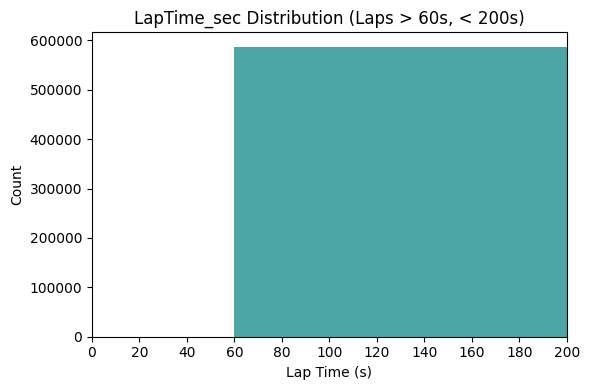


Unique raceId count: 544
Unique driverId count: 143


In [ ]:
# --- 1. Check lap_times after cleaning ---
print("\nColumns:", lap_times.columns)
print(lap_times.head())

# Add the conversion from milliseconds to LapTime_sec
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

# Filter out laps <= 60 seconds
lap_times = lap_times[lap_times["LapTime_sec"] > 60].copy()

print("\nLapTime_sec summary (Laps > 60s):")
print(lap_times["LapTime_sec"].describe())

plt.figure(figsize=(6,4))
plt.hist(lap_times["LapTime_sec"], bins=50, color='teal', alpha=0.7)

# ---- FIX: X-axis with multiples of 20 seconds ----
# Limit the max_time for the histogram's x-axis to a more reasonable range
# as most laps are under 200 seconds, to better visualize the main distribution.
max_time_for_plot = 200  # Set a reasonable upper limit for the x-axis
ticks = list(range(0, int(max_time_for_plot) + 20, 20))
plt.xticks(ticks)
plt.xlim(0, max_time_for_plot) # Set x-axis limits for the plot

plt.xlabel("Lap Time (s)")
plt.ylabel("Count")
plt.title("LapTime_sec Distribution (Laps > 60s, < 200s)")
plt.tight_layout()
plt.show()

print("\nUnique raceId count:", lap_times['raceId'].nunique())
print("Unique driverId count:", lap_times['driverId'].nunique())


In [ ]:
import os, numpy as np, pandas as pd

# ------------------------------------------------------------
# Helper functions to find/load CSVs anywhere under /content
# ------------------------------------------------------------
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    for root in ("/content", "/content/Project", "/content/drive/MyDrive"):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                print(f"✓ Found {filename} → {p}")
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# ------------------------------------------------------------
# 1) Load lap times + convert to seconds
# ------------------------------------------------------------
lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = (
    pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
)
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()

# ------------------------------------------------------------
# 2) Load engineered features & metadata
# ------------------------------------------------------------
fuel      = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit  = load_csv_anywhere("features_laps_before_pit.csv")
num_pit   = load_csv_anywhere("features_num_pitstops.csv")
prev_st   = load_csv_anywhere("features_prev_race_standing.csv")
races     = load_csv_anywhere("races.csv")
results   = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()

# Mean laps before pit per race/driver
laps_avg = (
    laps_pit.groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
    .mean()
    .rename(columns={"LapsBeforePit":"AvgLapsBeforePit"})
)

# ------------------------------------------------------------
# 3) Merge EVERYTHING into a single lap-level dataframe
# ------------------------------------------------------------
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# ------------------------------------------------------------
# 4) Clean
# ------------------------------------------------------------
df = df.dropna(subset=[
    "LapTime_sec","FuelLoadProxy","NumPitStops",
    "AvgLapsBeforePit","PrevRaceStanding",
    "circuitId","driverId","constructorId"
])

# Remove pit, safety-car, and broken laps (>200s)
df = df[df["LapTime_sec"] < 200]

# Additional clean: remove outlier laps per race (>1.5× median)
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# ------------------------------------------------------------
# 5) Additional model features (lap²)
# ------------------------------------------------------------
df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["LapSquared"] = df["lap"]**2

# ------------------------------------------------------------
# 6) One-hot encode circuitId, driverId, constructorId
# ------------------------------------------------------------
# Convert to string so get_dummies treats them as categorical
df["circuitId"] = df["circuitId"].astype(str)
df["driverId"] = df["driverId"].astype(str)
df["constructorId"] = df["constructorId"].astype(str)

df_encoded = pd.get_dummies(
    df,
    columns=["circuitId", "driverId", "constructorId"],
    drop_first=True
)

print("Final encoded dataframe shape:", df_encoded.shape)
print(df_encoded.head())

# ------------------------------------------------------------
# df_encoded now contains ALL features you used for:
# - OLS
# - OLS + lap²
# - Ridge
#
# TARGET:
#   LapTime_sec
#
# NUMERIC FEATURES:
#   NumPitStops, AvgLapsBeforePit, PrevRaceStanding
#   FuelLoadProxy, lap, LapSquared
#
# CATEGORICAL (encoded):
#   circuitId_*
#   driverId_*
#   constructorId_*
# ------------------------------------------------------------


✓ Found lap_times.csv → /content/Project/Project/lap_times.csv
✓ Found features_fuel_load_proxy.csv → /content/Project/Project/features_fuel_load_proxy.csv
✓ Found features_laps_before_pit.csv → /content/Project/Project/features_laps_before_pit.csv
✓ Found features_num_pitstops.csv → /content/Project/Project/features_num_pitstops.csv
✓ Found features_prev_race_standing.csv → /content/Project/Project/features_prev_race_standing.csv
✓ Found races.csv → /content/Project/Project/races.csv
✓ Found results.csv → /content/Project/Project/results.csv


/tmp/ipython-input-2758607635.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(


Final encoded dataframe shape: (295983, 137)
      raceId  lap  LapTime_sec  FuelLoadProxy  NumPitStops  AvgLapsBeforePit  \
1083     842    1      109.614       0.982143          3.0         13.333333   
1084     842    2      104.539       0.964286          3.0         13.333333   
1085     842    3      104.209       0.946429          3.0         13.333333   
1086     842    4      104.369       0.928571          3.0         13.333333   
1087     842    5      104.378       0.910714          3.0         13.333333   

      PrevRaceStanding  year  LapSquared  circuitId_10  ...  \
1083               1.0  2011           1         False  ...   
1084               1.0  2011           4         False  ...   
1085               1.0  2011           9         False  ...   
1086               1.0  2011          16         False  ...   
1087               1.0  2011          25         False  ...   

      constructorId_211  constructorId_213  constructorId_214  \
1083              False       

### OLS Linear Regression with Train/Validation/Test Split

This cell implements the OLS regression model with a refined approach to data splitting: 70% for training, 15% for validation, and 15% for testing. Unlike the previous cells, this explicitly separates a validation set to tune hyperparameters (if we were doing regularization, for instance) and a final, unseen test set for unbiased evaluation.

**Key Changes:**
1.  **70/15/15 Split:** The data is now split into three distinct sets: training, validation, and testing.
2.  **OLS without Regularization:** The model is a simple OLS regression, without any L2 regularization, allowing us to see the baseline performance with this new data split strategy.

✓ Found lap_times.csv → /content/Project/Project/lap_times.csv
✓ Found features_fuel_load_proxy.csv → /content/Project/Project/features_fuel_load_proxy.csv
✓ Found features_laps_before_pit.csv → /content/Project/Project/features_laps_before_pit.csv
✓ Found features_num_pitstops.csv → /content/Project/Project/features_num_pitstops.csv
✓ Found features_prev_race_standing.csv → /content/Project/Project/features_prev_race_standing.csv
✓ Found races.csv → /content/Project/Project/races.csv
✓ Found results.csv → /content/Project/Project/results.csv


/tmp/ipython-input-4061568427.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(


Shapes → Train: (206518, 134), Val: (44264, 134), Test: (44256, 134)

=== OLS (train on 70%) ===
Train      R²=0.679  MAE=4.957s  RMSE=8.493s  SSE=1.490e+07
Val        R²=0.674  MAE=4.989s  RMSE=8.590s  SSE=3.266e+06
Test       R²=0.675  MAE=4.977s  RMSE=8.580s  SSE=3.258e+06


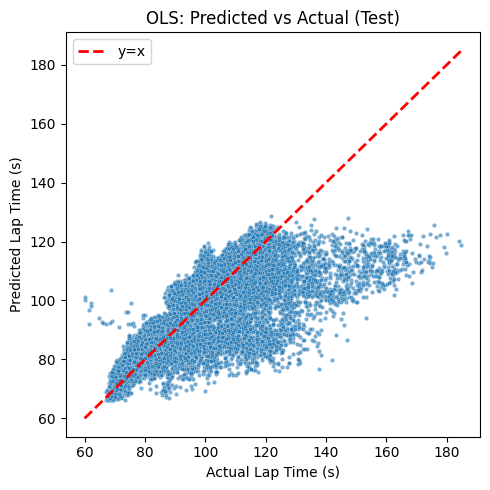

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import os

# --- Helper functions (copied from earlier cells for self-containment) ---
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    for root in ("/content", "/content/Project", "/content/drive/MyDrive"):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                print(f"✓ Found {filename} \u2192 {p}")
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# --- Load lap times and initial features to recreate 'df' ---
lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

fuel     = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit = load_csv_anywhere("features_laps_before_pit.csv")
num_pit  = load_csv_anywhere("features_num_pitstops.csv")
prev_st  = load_csv_anywhere("features_prev_race_standing.csv")
races    = load_csv_anywhere("races.csv")
results  = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()

# Average laps-before-pit per race-driver
laps_avg = (
laps_pit.groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
.mean().rename(columns={"LapsBeforePit":"AvgLapsBeforePit"}))

# --- Merge everything to create the base df ---
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# --- Clean + filter outliers ---
df = df.dropna(subset=["LapTime_sec","FuelLoadProxy","NumPitStops",
                       "AvgLapsBeforePit","PrevRaceStanding","circuitId",
                       "driverId","constructorId"])
# remove very long laps (pit/safety) and very short laps (anomalies)
df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

# remove laps > 1.5\u00d7 median for that race
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# --- Create new features ---
df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["LapSquared"] = df["lap"] ** 2

# Convert IDs to strings for one-hot encoding
for col in ["circuitId","driverId","constructorId"]:
    df[col] = df[col].astype(str)

# --- One-hot encode categorical columns ---
df_encoded = pd.get_dummies(df,
                            columns=["circuitId","driverId","constructorId"],
                            drop_first=True)

# --- Define features and target ---
base_features = ["NumPitStops","AvgLapsBeforePit","PrevRaceStanding",
                 "FuelLoadProxy","lap","LapSquared"]
# add dummy features
cat_features = [c for c in df_encoded.columns
                if c.startswith(("circuitId_","driverId_","constructorId_"))]

features = base_features + cat_features

# ===============================================================
# OLS LINEAR REGRESSION \u2014 Train / Validation / Test (70/15/15) Split
# ===============================================================

# 1) Build X, y from df_encoded safely (numeric only)
X = df_encoded[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")
mask = X.notna().all(axis=1) & y.notna()
X, y = X.loc[mask].astype(float), y.loc[mask].astype(float)

# 2) 70/15/15 split: (train+val) vs test, then train vs val
X_tr_val, X_te, y_tr_val, y_te = train_test_split(X, y, test_size=0.15, random_state=42)
X_tr, X_va,  y_tr,  y_va      = train_test_split(X_tr_val, y_tr_val, test_size=0.1765, random_state=42)
# (0.1765 of 85% \u2248 15% overall \u2192 70/15/15)

print(f"Shapes \u2192 Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}")

# ---------- helpers ----------
def eval_metrics(y_true, y_pred, label="Set"):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse = float(np.sum((y_true - y_pred)**2))
    print(f"{label:<10} R\u00b2={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

def scatter_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=y_true, y=y_pred, s=10, alpha=0.6)
    lo, hi = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
    plt.plot([lo,hi],[lo,hi],'r--',lw=2,label='y=x')
    plt.xlabel("Actual Lap Time (s)"); plt.ylabel("Predicted Lap Time (s)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# ---------- 3) OLS on train, eval on val & test ----------
X_tr_const = sm.add_constant(X_tr)
X_va_const = sm.add_constant(X_va, has_constant='add')
X_te_const = sm.add_constant(X_te, has_constant='add')

ols = sm.OLS(y_tr, X_tr_const).fit()

print("\n=== OLS (train on 70%) ===")
y_tr_hat = ols.predict(X_tr_const); _ = eval_metrics(y_tr, y_tr_hat, "Train")
y_va_hat = ols.predict(X_va_const); _ = eval_metrics(y_va, y_va_hat, "Val")
y_te_hat = ols.predict(X_te_const); _ = eval_metrics(y_te, y_te_hat, "Test")

scatter_plot(y_te, y_te_hat, "OLS: Predicted vs Actual (Test)")

In [ ]:
#Inspect the merged training dataframe
#Let’s inspect what’s actually being fed into the regression:

print("\nMerged DF preview:")
print(df.head())

# Describe each feature
feat_cols = ["NumPitStops","AvgLapsBeforePit","PrevRaceStanding","FuelLoadProxy"]
print("\nFeature summary:")
print(df[feat_cols].describe().T[["min","max","mean","std"]])

# Check number of unique values
print("\nUnique values per feature:")
print(df[feat_cols].nunique())

# Correlation with LapTime_sec
print("\nCorrelation with LapTime_sec:")
print(df[feat_cols + ["LapTime_sec"]].corr()["LapTime_sec"].sort_values(ascending=False))



Merged DF preview:
      raceId driverId  lap  LapTime_sec  FuelLoadProxy  NumPitStops  \
1083     842       20    1      109.614       0.982143          3.0   
1084     842       20    2      104.539       0.964286          3.0   
1085     842       20    3      104.209       0.946429          3.0   
1086     842       20    4      104.369       0.928571          3.0   
1087     842       20    5      104.378       0.910714          3.0   

      AvgLapsBeforePit  PrevRaceStanding circuitId  year constructorId  \
1083         13.333333               1.0         2  2011             9   
1084         13.333333               1.0         2  2011             9   
1085         13.333333               1.0         2  2011             9   
1086         13.333333               1.0         2  2011             9   
1087         13.333333               1.0         2  2011             9   

      LapSquared  
1083           1  
1084           4  
1085           9  
1086          16  
1087         

In [ ]:
race_sample = df[df["raceId"] == df["raceId"].sample(1, random_state=0).iloc[0]]
print(race_sample[["LapTime_sec","FuelLoadProxy","AvgLapsBeforePit"]].corr())


                  LapTime_sec  FuelLoadProxy  AvgLapsBeforePit
LapTime_sec          1.000000      -0.069340          0.013182
FuelLoadProxy       -0.069340       1.000000         -0.013663
AvgLapsBeforePit     0.013182      -0.013663          1.000000


**What our results mean**:<br>
**R^2**: The model captures just over half the lap-time variability. That’s strong given the simplicity of the features (no weather, tires, or driver effects).
<br>
**MAE**: On average, predictions are off by ~6-7 s. This is good but can still be improved. In racing every second matters.
<br>
**RMSE**: Big outliers (e.g. slow in-laps, traffic) occasionally produce errors 2× larger than MAE.
<br>
**SSE:** Total squared deviation. Large number because you have many samples (hundreds of thousands of laps). Also, we can see that at some point the predictions are no where near accurate.

**Further Analysis**
<br>The red dashed line (y = x) is where perfect predictions would lie.
Our cloud of blue points sits mostly below that line and in a diagonal shape. it looks like the regression is under predicting slower laps and over predicting faster laps.
That pattern means the model has captured the general scale of lap times but is missing part of the track specific offset.

**To Fix More**<br>
We are at the stage where adding richer features will straighten that wedge:
1. Add driverId and constructorId as categorical dummies → captures baseline performance gaps.
2. Add lap and lap² → models the within-stint fuel/tire curve.

### OLS Linear Regression with `LapsSincePit` and `LapsSincePitSquared`

This cell implements the OLS regression model with a refined approach to modeling tire wear. Instead of using the absolute lap number and its square (`lap`, `LapSquared`), it calculates the number of laps completed *since the last pit stop* (`LapsSincePit`) and its square (`LapsSincePitSquared`). This aims to more accurately capture the degradation of tires, which reset with each pit stop.

**Key Changes:**
1.  **`LapsSincePit` calculation:** For each lap, the code determines how many laps have passed since the driver's most recent pit stop.
2.  **`LapsSincePitSquared`:** This new feature is derived from `LapsSincePit` to model non-linear tire degradation.
3.  **Feature Update:** `lap` and `LapSquared` are replaced by `LapsSincePit` and `LapsSincePitSquared` in the model's features.

This modification directly addresses the idea of resetting the 'tire wear clock' after new tires are fitted during a pit stop.

✓ Found lap_times.csv → /content/Project/Project/lap_times.csv

✅ Lap times parsed correctly:
count    589081.000000
mean         95.799445
std          76.399730
min          55.404000
25%          82.041000
50%          90.608000
75%         101.930000
max        7507.547000
Name: LapTime_sec, dtype: float64
✓ Found features_fuel_load_proxy.csv → /content/Project/Project/features_fuel_load_proxy.csv
✓ Found features_laps_before_pit.csv → /content/Project/Project/features_laps_before_pit.csv
✓ Found features_num_pitstops.csv → /content/Project/Project/features_num_pitstops.csv
✓ Found features_prev_race_standing.csv → /content/Project/Project/features_prev_race_standing.csv
✓ Found races.csv → /content/Project/Project/races.csv
Filtered races to post-2010: 305 races remaining.
✓ Found results.csv → /content/Project/Project/results.csv
✓ Found pit_stops.csv → /content/Project/Project/pit_stops.csv


/tmp/ipython-input-1479355163.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(



Dataset after cleaning: (295038, 11)

==================== OLS SUMMARY ====================
                            OLS Regression Results                            
Dep. Variable:            LapTime_sec   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     3868.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        08:08:47   Log-Likelihood:            -8.3700e+05
No. Observations:              236030   AIC:                         1.674e+06
Df Residuals:                  235895   BIC:                         1.676e+06
Df Model:                         134                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

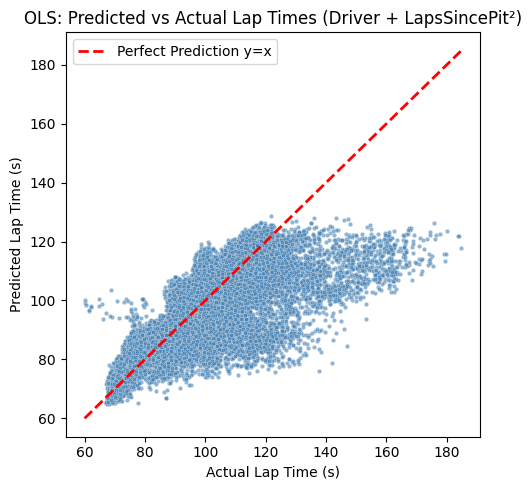

In [ ]:
# ===============================================================
# OLS LINEAR REGRESSION — Lap Time Prediction (Driver + Constructor + LapsSincePit²)
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# --- 1) Helper functions ---
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    for root in ("/content", "/content/Project", "/content/drive/MyDrive"):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                print(f"✓ Found {filename} → {p}")
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# --- 2) Load lap times ---
lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

print("\n✅ Lap times parsed correctly:")
print(lap_times["LapTime_sec"].describe())

# --- 3) Load engineered features + races + results + pit_stops ---
fuel     = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit = load_csv_anywhere("features_laps_before_pit.csv")
num_pit  = load_csv_anywhere("features_num_pitstops.csv")
prev_st  = load_csv_anywhere("features_prev_race_standing.csv")
races    = load_csv_anywhere("races.csv")
# Filter races for post-2010 era (refueling ban)
races = races[races['year'] >= 2010].copy()
print(f"Filtered races to post-2010: {races.shape[0]} races remaining.")

results  = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()
pit_stops = load_csv_anywhere("pit_stops.csv")

# Apply the 1-4 pit stop filter before using pit_stops for LapsSincePit calculation
pit_stops = pit_stops[pit_stops["stop"].between(1, 4)].copy()

# Average laps-before-pit per race-driver
laps_avg = (laps_pit.groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
            .mean().rename(columns={"LapsBeforePit":"AvgLapsBeforePit"}))

# --- 4) Merge everything (keep lap-level FuelLoadProxy) ---
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# --- 5) Clean + filter outliers ---
df = df.dropna(subset=["LapTime_sec","FuelLoadProxy","NumPitStops",
                       "AvgLapsBeforePit","PrevRaceStanding","circuitId",
                       "driverId","constructorId"])
# remove very long laps (pit/safety) and very short laps (anomalies)
df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

# remove laps > 1.5× median for that race
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

print(f"\nDataset after cleaning: {df.shape}")

# --- 6) Create new features: LapsSincePit and LapsSincePitSquared ---
# Build a dictionary: {(raceId, driverId): [pit lap numbers]}
pit_laps = (
    pit_stops.groupby(["raceId", "driverId"])["lap"]
    .apply(list)
    .to_dict()
)

# Helper function: laps since last pit stop
def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df["LapsSincePit"] = df.apply(laps_since_last_pit, axis=1)
df["LapsSincePitSquared"] = df["LapsSincePit"] ** 2

# Convert IDs to strings for one-hot encoding
for col in ["circuitId","driverId","constructorId"]:
    df[col] = df[col].astype(str)

# --- 7) One-hot encode categorical columns ---
df_encoded = pd.get_dummies(df,
                            columns=["circuitId","driverId","constructorId"],
                            drop_first=True)

# --- 8) Define features and target ---
base_features = ["NumPitStops","AvgLapsBeforePit","PrevRaceStanding",
                 "FuelLoadProxy","LapsSincePit","LapsSincePitSquared"]
# add dummy features
cat_features = [c for c in df_encoded.columns
                if c.startswith(("circuitId_","driverId_","constructorId_"))]

features = base_features + cat_features

X = df_encoded[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X, y = X.loc[mask].astype(float), y.loc[mask].astype(float)

X_const = sm.add_constant(X)

# --- 9) Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(X_const, y,
                                                    test_size=0.2, random_state=42)

# --- 10) Fit OLS model ---
model = sm.OLS(y_train, X_train).fit()
print("\n==================== OLS SUMMARY ====================")
print(model.summary())

# --- 11) Evaluate on test set ---
y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
sse = np.sum((y_test - y_pred)**2)

print("\n==================== EVALUATION ====================")
print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.3f} s")
print(f"RMSE : {rmse:.3f} s")
print(f"SSE  : {sse:.3e}")

# --- 12) Plot predicted vs actual ---
plt.figure(figsize=(5,5))
sns.scatterplot(x=y_test, y=y_pred, s=10, alpha=0.6, color="steelblue")
lims = [float(min(y_test.min(), y_pred.min())),
        float(max(y_test.max(), y_pred.min()))]
plt.plot(lims, lims, 'r--', lw=2, label="Perfect Prediction y=x")
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("OLS: Predicted vs Actual Lap Times (Driver + LapsSincePit²)")
plt.legend()
plt.tight_layout()
plt.show()


### OLS Linear Regression with Train/Validation/Test Split and Ridge (L2) Regularization

This cell extends the OLS regression by introducing Ridge (L2) regularization. The data is split into 70% training, 15% validation, and 15% testing sets. The validation set is used to tune the `alpha` hyperparameter for Ridge regression, selecting the value that yields the best R² score.

**Key Changes:**
1.  **Ridge Regression:** An `sklearn.linear_model.Ridge` model is applied.
2.  **`alpha` Tuning:** The `alpha` hyperparameter (regularization strength) is optimized using the validation set.
3.  **StandardScaler:** Features are scaled before applying Ridge regression, which is standard practice for regularized models.

Much better! But still can be improved.
The plot now captures the trend of the line more than before. <br>Our last shor will be trying L2 regularization to "weigh" the importance of the features. However, we dont want any features completely gone, so we wont ry L1. This way, OLS wont treat all features equally. Also, we will add a validation set split not just test and train.

Seperation


✓ Found lap_times.csv → /content/Project/Project/lap_times.csv

✅ Lap times parsed correctly:
count    589081.000000
mean         95.799445
std          76.399730
min          55.404000
25%          82.041000
50%          90.608000
75%         101.930000
max        7507.547000
Name: LapTime_sec, dtype: float64
✓ Found features_fuel_load_proxy.csv → /content/Project/Project/features_fuel_load_proxy.csv
✓ Found features_laps_before_pit.csv → /content/Project/Project/features_laps_before_pit.csv
✓ Found features_num_pitstops.csv → /content/Project/Project/features_num_pitstops.csv
✓ Found features_prev_race_standing.csv → /content/Project/Project/features_prev_race_standing.csv
✓ Found races.csv → /content/Project/Project/races.csv
✓ Found results.csv → /content/Project/Project/results.csv


/tmp/ipython-input-2250121205.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("raceId", group_keys=False).apply(



Dataset after cleaning: (295038, 11)

==================== OLS SUMMARY ====================
                            OLS Regression Results                            
Dep. Variable:            LapTime_sec   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     3714.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        08:09:28   Log-Likelihood:            -8.4028e+05
No. Observations:              236030   AIC:                         1.681e+06
Df Residuals:                  235895   BIC:                         1.682e+06
Df Model:                         134                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

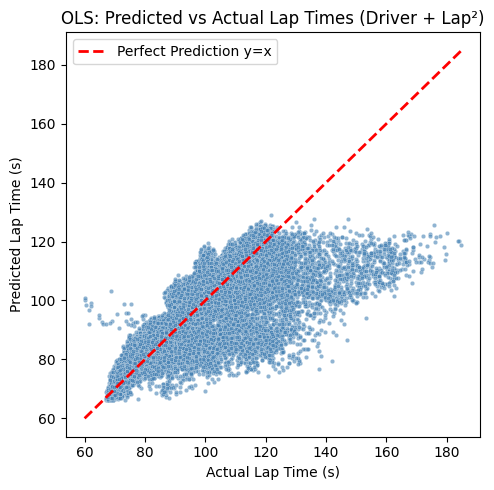

In [ ]:
# ===============================================================
# OLS LINEAR REGRESSION — Lap Time Prediction (Driver + Constructor + Lap²)
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# --- 1) Helper functions ---
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    for root in ("/content", "/content/Project", "/content/drive/MyDrive"):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                print(f"✓ Found {filename} → {p}")
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# --- 2) Load lap times ---
lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

print("\n✅ Lap times parsed correctly:")
print(lap_times["LapTime_sec"].describe())

# --- 3) Load engineered features + races + results ---
fuel     = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit = load_csv_anywhere("features_laps_before_pit.csv")
num_pit  = load_csv_anywhere("features_num_pitstops.csv")
prev_st  = load_csv_anywhere("features_prev_race_standing.csv")
races    = load_csv_anywhere("races.csv")
results  = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()

# Average laps-before-pit per race-driver
laps_avg = (laps_pit.groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
            .mean().rename(columns={"LapsBeforePit":"AvgLapsBeforePit"}))

# --- 4) Merge everything (keep lap-level FuelLoadProxy) ---
df = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# --- 5) Clean + filter outliers ---
df = df.dropna(subset=["LapTime_sec","FuelLoadProxy","NumPitStops",
                       "AvgLapsBeforePit","PrevRaceStanding","circuitId",
                       "driverId","constructorId"])
# remove very long laps (pit/safety) and very short laps (anomalies)
df = df[df["LapTime_sec"] < 200]
df = df[df["LapTime_sec"] > 60]

# remove laps > 1.5× median for that race
df = df.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

print(f"\nDataset after cleaning: {df.shape}")

# --- 6) Create new features ---
df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["LapSquared"] = df["lap"] ** 2

# Convert IDs to strings for one-hot encoding
for col in ["circuitId","driverId","constructorId"]:
    df[col] = df[col].astype(str)

# --- 7) One-hot encode categorical columns ---
df_encoded = pd.get_dummies(df,
                            columns=["circuitId","driverId","constructorId"],
                            drop_first=True)

# --- 8) Define features and target ---
base_features = ["NumPitStops","AvgLapsBeforePit","PrevRaceStanding",
                 "FuelLoadProxy","lap","LapSquared"]
# add dummy features
cat_features = [c for c in df_encoded.columns
                if c.startswith(("circuitId_","driverId_","constructorId_"))]

features = base_features + cat_features

X = df_encoded[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_encoded["LapTime_sec"], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X, y = X.loc[mask].astype(float), y.loc[mask].astype(float)

X_const = sm.add_constant(X)

# --- 9) Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(X_const, y,
                                                    test_size=0.2, random_state=42)

# --- 10) Fit OLS model ---
model = sm.OLS(y_train, X_train).fit()
print("\n==================== OLS SUMMARY ====================")
print(model.summary())

# --- 11) Evaluate on test set ---
y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
sse = np.sum((y_test - y_pred)**2)

print("\n==================== EVALUATION ====================")
print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.3f} s")
print(f"RMSE : {rmse:.3f} s")
print(f"SSE  : {sse:.3e}")

# --- 12) Plot predicted vs actual ---
plt.figure(figsize=(5,5))
sns.scatterplot(x=y_test, y=y_pred, s=10, alpha=0.6, color="steelblue")
lims = [float(min(y_test.min(), y_pred.min())),
        float(max(y_test.max(), y_pred.max()))]
plt.plot(lims, lims, 'r--', lw=2, label="Perfect Prediction y=x")
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("OLS: Predicted vs Actual Lap Times (Driver + Lap²)")
plt.legend()
plt.tight_layout()
plt.show()


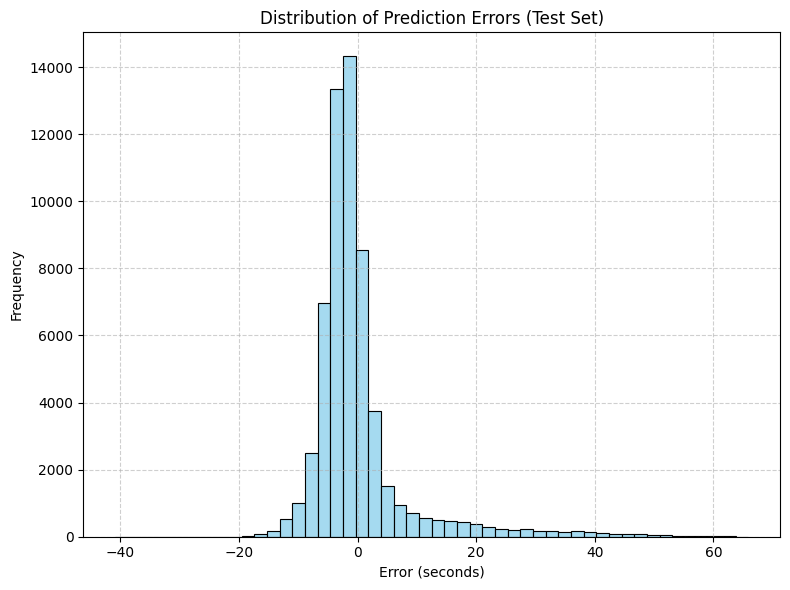

In [ ]:
# Calculate errors from the predictions of the last OLS model (bc2a5227)
errors = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Errors (Test Set)')
plt.xlabel('Error (seconds)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The model did not improve under L2 regularization. We will need to think of other methods to make this model better.

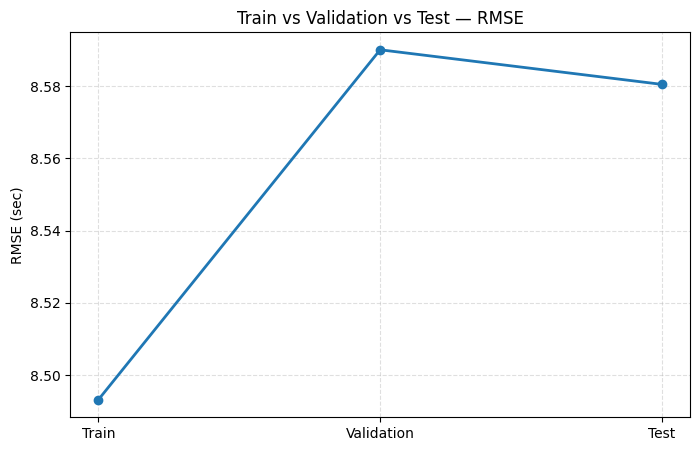

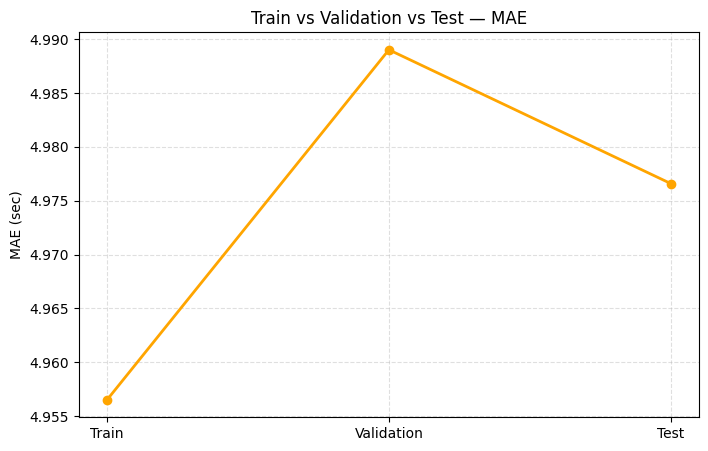

RMSE: 8.493165602746119 8.59000859288329 8.580431861890496
MAE : 4.956510274892788 4.989024723646178 4.976598801957644


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# ---- Compute metrics from existing variables ----
train_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_hat))
val_rmse   = np.sqrt(mean_squared_error(y_va, y_va_hat))
test_rmse  = np.sqrt(mean_squared_error(y_te, y_te_hat))

train_mae = mean_absolute_error(y_tr, y_tr_hat)
val_mae   = mean_absolute_error(y_va, y_va_hat)
test_mae  = mean_absolute_error(y_te, y_te_hat)

# ---- Plot RMSE ----
plt.figure(figsize=(8,5))
plt.plot(["Train","Validation","Test"],
         [train_rmse, val_rmse, test_rmse],
         marker='o', linewidth=2)
plt.title("Train vs Validation vs Test — RMSE")
plt.ylabel("RMSE (sec)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ---- Plot MAE ----
plt.figure(figsize=(8,5))
plt.plot(["Train","Validation","Test"],
         [train_mae, val_mae, test_mae],
         marker='o', linewidth=2, color='orange')
plt.title("Train vs Validation vs Test — MAE")
plt.ylabel("MAE (sec)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("RMSE:", train_rmse, val_rmse, test_rmse)
print("MAE :", train_mae, val_mae, test_mae)


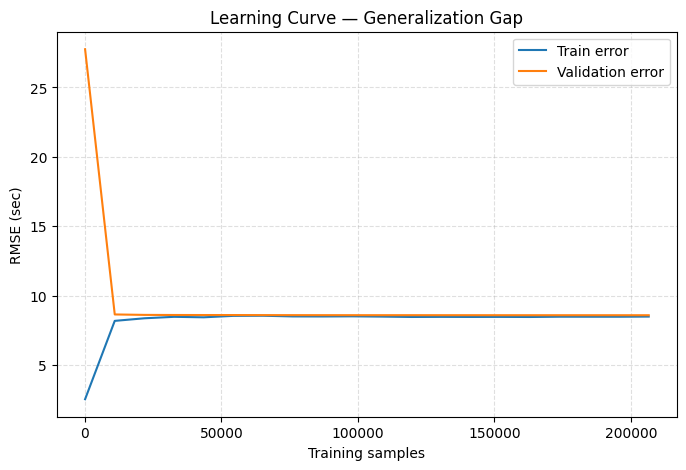

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# We will use a simple model you already trained — for example OLS
# But we retrain it on progressively larger subsets of X_tr, y_tr.

from sklearn.linear_model import LinearRegression
# (you can change to Ridge(), SGDRegressor(), etc.)

train_errors = []
val_errors = []
sizes = np.linspace(100, len(X_tr), 20, dtype=int)  # 20 points from 100 → full training size

for m in sizes:
    # subset first m samples
    X_sub = X_tr[:m]
    y_sub = y_tr[:m]

    # train model
    model = LinearRegression()
    model.fit(X_sub, y_sub)

    # predict on train subset
    y_sub_hat = model.predict(X_sub)
    train_rmse = np.sqrt(mean_squared_error(y_sub, y_sub_hat))

    # predict on validation set
    y_val_hat = model.predict(X_va)
    val_rmse = np.sqrt(mean_squared_error(y_va, y_val_hat))

    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

# ----- Plot -----
plt.figure(figsize=(8,5))
plt.plot(sizes, train_errors, label="Train error")
plt.plot(sizes, val_errors, label="Validation error")
plt.xlabel("Training samples")
plt.ylabel("RMSE (sec)")
plt.title("Learning Curve — Generalization Gap")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


Model is stable, starts doing very well at even 100000 samples
Add nonlinear features:

LapsSincePitCubed  Tire degradation is strongly convex

FuelLoadProxySquared   Heavy fuel makes early-stint tire wear worse, which is nonlinear

Fuel_Tire_Interaction   Heavy fuel makes early-stint tire wear worse, which is nonlinear

LapNumberSquared   Track evolution, ambient temperature, and fuel load interact over time


IsOutLap  This captures the nonlinear drop in grip right after new tires are fitted.

-------------------------------------------

---------------------------------------

# Task
Generate a new code cell implementing `sklearn.linear_model.SGDRegressor`. This cell will perform the 70/15/15 train/validation/test split on the globally prepared `X` and `y` data, apply `StandardScaler` to the features, and then tune the `alpha` (L2 regularization strength) parameter for `SGDRegressor` by iterating through a range of `alpha` values and selecting the one that yields the best R² score on the validation set. The best performing `SGDRegressor` model will be stored.

Shapes → Train: (206518, 135), Val: (44264, 135), Test: (44256, 135)

--- Tuning SGDRegressor alpha ---
Alpha: 0.000001, R² on Val: 0.682
Alpha: 0.000010, R² on Val: 0.682
Alpha: 0.000100, R² on Val: 0.682
Alpha: 0.001000, R² on Val: 0.682
Alpha: 0.010000, R² on Val: 0.681
Alpha: 0.100000, R² on Val: 0.671
Alpha: 1.000000, R² on Val: 0.532

Best Alpha: 0.000100 with R² on Val: 0.682

=== Best SGDRegressor Model Evaluation ===
Test       R²=0.680  MAE=5.067s  RMSE=8.483s  SSE=3.185e+06


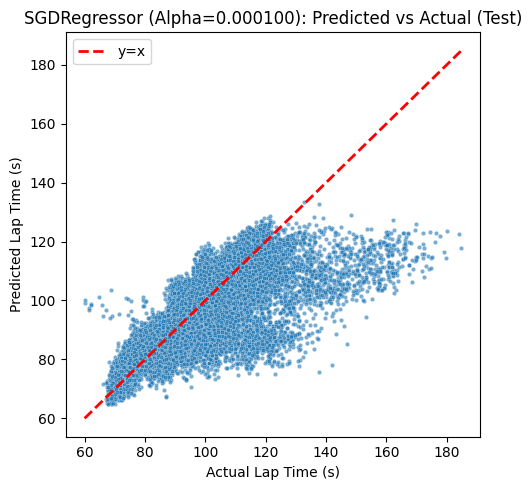

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

# --- Helper functions (redefined for cell execution independence) ---
def eval_metrics(y_true, y_pred, label="Set"):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse = float(np.sum((y_true - y_pred)**2))
    print(f"{label:<10} R²={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

def scatter_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=y_true, y=y_pred, s=10, alpha=0.6)
    lo, hi = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
    plt.plot([lo,hi],[lo,hi],'r--',lw=2,label='y=x')
    plt.xlabel("Actual Lap Time (s)"); plt.ylabel("Predicted Lap Time (s)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# 1) 70/15/15 split: (train+val) vs test, then train vs val
X_tr_val, X_te, y_tr_val, y_te = train_test_split(X, y, test_size=0.15, random_state=42)
X_tr, X_va,  y_tr,  y_va      = train_test_split(X_tr_val, y_tr_val, test_size=0.1765, random_state=42)
# (0.1765 of 85% ≈ 15% overall → 70/15/15)

print(f"Shapes → Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}")

# 2) Define a range of alpha values to tune
alphas = np.logspace(-6, 0, 7) # Example: [1e-06, 1e-05, ..., 1]

best_r2 = -np.inf
best_alpha = None
best_model = None

results = []

print("\n--- Tuning SGDRegressor alpha ---")
for alpha in alphas:
    # Create a pipeline with StandardScaler and SGDRegressor
    model_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('sgd', SGDRegressor(alpha=alpha, random_state=42, max_iter=1000, tol=1e-3))
    ])

    # Train the model
    model_pipeline.fit(X_tr, y_tr)

    # Evaluate on validation set
    y_va_hat = model_pipeline.predict(X_va)
    r2_va = r2_score(y_va, y_va_hat)

    results.append({"alpha": alpha, "r2_val": r2_va})

    if r2_va > best_r2:
        best_r2 = r2_va
        best_alpha = alpha
        best_model = model_pipeline
    print(f"Alpha: {alpha:<8.6f}, R² on Val: {r2_va:.3f}")

print(f"\nBest Alpha: {best_alpha:.6f} with R² on Val: {best_r2:.3f}")

# 3) Evaluate the best model on the test set
print("\n=== Best SGDRegressor Model Evaluation ===")
y_te_hat = best_model.predict(X_te)
_ = eval_metrics(y_te, y_te_hat, "Test")

# 4) Plot predicted vs actual for the test set
scatter_plot(y_te, y_te_hat, f"SGDRegressor (Alpha={best_alpha:.6f}): Predicted vs Actual (Test)")


Added Interaction feature between driver and circuit


In [ ]:
import psutil
print(f"RAM used: {psutil.virtual_memory().used / 1e9:.2f} GB")
print(f"RAM total: {psutil.virtual_memory().total / 1e9:.2f} GB")


RAM used: 1.08 GB
RAM total: 13.61 GB


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# --- Helper functions (redefined for cell execution independence) ---
def eval_metrics(y_true, y_pred, label="Set"):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sse = float(np.sum((y_true - y_pred)**2))
    print(f"{label:<10} R²={r2:.3f}  MAE={mae:.3f}s  RMSE={rmse:.3f}s  SSE={sse:.3e}")
    return r2, mae, rmse, sse

def scatter_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=y_true, y=y_pred, s=10, alpha=0.6)
    lo, hi = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
    plt.plot([lo,hi],[lo,hi],'r--',lw=2,label='y=x')
    plt.xlabel("Actual Lap Time (s)"); plt.ylabel("Predicted Lap Time (s)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()


print("--- Starting OLS with Driver-Circuit Interaction Feature ---")

# 1) Create a copy of the main DataFrame to add interaction features
df_with_interaction = df.copy()

# 2) Create the driver-circuit interaction feature
df_with_interaction['driver_circuit_interaction'] = df_with_interaction['driverId'].astype(str) + '_' + df_with_interaction['circuitId'].astype(str)

# 3) Convert IDs to strings for one-hot encoding
for col in ["circuitId","driverId","constructorId", 'driver_circuit_interaction']:
    df_with_interaction[col] = df_with_interaction[col].astype(str)

# 4) One-hot encode categorical columns
df_encoded_interaction = pd.get_dummies(df_with_interaction,
                                        columns=["circuitId","driverId","constructorId", 'driver_circuit_interaction'],
                                        drop_first=True)

# 5) Define features and target
# Re-using the base_features from the previous successful OLS run
base_features = [
    "NumPitStops",
    "AvgLapsBeforePit",
    "PrevRaceStanding",
    "FuelLoadProxy",
    "LapsSincePit",
    "LapsSincePitSquared",
    "PitStopDuration_sec" # Added new feature
]

# Add dummy features, including the new interaction feature
cat_features_interaction = [c for c in df_encoded_interaction.columns
                            if c.startswith(("circuitId_","driverId_","constructorId_", "driver_circuit_interaction_"))]

features_interaction = base_features + cat_features_interaction

X_interaction = df_encoded_interaction[features_interaction].apply(pd.to_numeric, errors="coerce")
y_interaction = pd.to_numeric(df_encoded_interaction["LapTime_sec"], errors="coerce")

mask_interaction = X_interaction.notna().all(axis=1) & y_interaction.notna()
X_interaction, y_interaction = X_interaction.loc[mask_interaction].astype(float), y_interaction.loc[mask_interaction].astype(float)

print(f"\nShape of X with interaction feature: {X_interaction.shape}")
print(f"Shape of y with interaction feature: {y_interaction.shape}")

# 6) 70/15/15 split
X_tr_val_inter, X_te_inter, y_tr_val_inter, y_te_inter = train_test_split(X_interaction, y_interaction, test_size=0.15, random_state=42)
X_tr_inter, X_va_inter,  y_tr_inter,  y_va_inter      = train_test_split(X_tr_val_inter, y_tr_val_inter, test_size=0.1765, random_state=42)

print(f"Shapes → Train: {X_tr_inter.shape}, Val: {X_va_inter.shape}, Test: {X_te_inter.shape}")

# 7) Add a constant term to the feature sets for the OLS model
X_tr_const_inter = sm.add_constant(X_tr_inter)
X_va_const_inter = sm.add_constant(X_va_inter, has_constant='add')
X_te_const_inter = sm.add_constant(X_te_inter, has_constant='add')

# 8) Fit OLS model on the training data
ols_interaction = sm.OLS(y_tr_inter, X_tr_const_inter).fit()

print("\n=== OLS with Driver-Circuit Interaction (train on 70%) ===")
# 9) Predict and evaluate on train, validation, and test sets
y_tr_hat_inter = ols_interaction.predict(X_tr_const_inter); _ = eval_metrics(y_tr_inter, y_tr_hat_inter, "Train")
y_va_hat_inter = ols_interaction.predict(X_va_const_inter); _ = eval_metrics(y_va_inter, y_va_hat_inter, "Val")
y_te_hat_inter = ols_interaction.predict(X_te_const_inter); _ = eval_metrics(y_te_inter, y_te_hat_inter, "Test")

# 10) Plot predicted vs actual for the test set
scatter_plot(y_te_inter, y_te_hat_inter, "OLS: Predicted vs Actual (Test) with Driver-Circuit Interaction")


--- Starting OLS with Driver-Circuit Interaction Feature ---


NameError: name 'df' is not defined

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from sklearn.feature_extraction import FeatureHasher

# --- Helper functions (redefined for cell execution independence) ---
def find_csv(start_root, filename):
    target = filename.lower()
    for cur, _, files in os.walk(start_root):
        for f in files:
            if f.lower() == target:
                return os.path.join(cur, f)
    return None

def load_csv_anywhere(filename):
    for root in ("/content", "/content/Project", "/content/drive/MyDrive"):
        if os.path.isdir(root):
            p = find_csv(root, filename)
            if p:
                print(f"✓ Found {filename} \u2192 {p}")
                return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Could not find {filename}")

# --- Load lap times and initial features to recreate 'df' ---
# (Assuming `DATA_DIR` from earlier steps is available or auto-detected by load_csv_anywhere)

lap_times = load_csv_anywhere("lap_times.csv")
lap_times["LapTime_sec"] = pd.to_numeric(lap_times["milliseconds"], errors="coerce") / 1000.0
lap_times = lap_times.dropna(subset=["LapTime_sec"]).copy()
lap_times["LapTime_sec"] = lap_times["LapTime_sec"].astype(float)

fuel     = load_csv_anywhere("features_fuel_load_proxy.csv")
laps_pit = load_csv_anywhere("features_laps_before_pit.csv")
num_pit  = load_csv_anywhere("features_num_pitstops.csv")
prev_st  = load_csv_anywhere("features_prev_race_standing.csv")
races    = load_csv_anywhere("races.csv")
races = races[races['year'] >= 2010].copy() # Filter as in previous step

results  = load_csv_anywhere("results.csv")[["raceId","driverId","constructorId"]].drop_duplicates()
pit_stops_orig = load_csv_anywhere("pit_stops.csv") # Original pit stops for LapsSincePit

# Apply the 1-4 pit stop filter before using pit_stops_orig for LapsSincePit calculation
pit_stops_for_laps_since_pit = pit_stops_orig[pit_stops_orig["stop"].between(1, 4)].copy()

# Average laps-before-pit per race-driver
laps_avg = (
laps_pit.groupby(["raceId","driverId"], as_index=False)["LapsBeforePit"]
.mean().rename(columns={"LapsBeforePit":"AvgLapsBeforePit"}))

# --- Merge everything to create the base df ---
df_recreated = (
    lap_times[["raceId","driverId","lap","LapTime_sec"]]
    .merge(fuel[["raceId","driverId","lap","FuelLoadProxy"]],
           on=["raceId","driverId","lap"], how="left")
    .merge(num_pit,  on=["raceId","driverId"], how="left")
    .merge(laps_avg, on=["raceId","driverId"], how="left")
    .merge(prev_st,  on=["raceId","driverId"], how="left")
    .merge(races[["raceId","circuitId","year"]], on="raceId", how="left")
    .merge(results, on=["raceId","driverId"], how="left")
)

# --- Clean + filter outliers (as in previous step) ---
df_recreated = df_recreated.dropna(subset=["LapTime_sec","FuelLoadProxy","NumPitStops",
                       "AvgLapsBeforePit","PrevRaceStanding","circuitId",
                       "driverId","constructorId"])
df_recreated = df_recreated[df_recreated["LapTime_sec"] < 200]
df_recreated = df_recreated[df_recreated["LapTime_sec"] > 60]
df_recreated = df_recreated.groupby("raceId", group_keys=False).apply(
    lambda g: g[g["LapTime_sec"] < 1.5 * g["LapTime_sec"].median()]
)

# --- Create LapsSincePit and LapsSincePitSquared (as in previous step) ---
pit_laps = (
    pit_stops_for_laps_since_pit.groupby(["raceId", "driverId"])[["lap"]]
    .apply(lambda x: sorted(x["lap"].unique().tolist()))
    .to_dict()
)

def laps_since_last_pit(row):
    pits = pit_laps.get((row["raceId"], row["driverId"]), [])
    pits_before = [p for p in pits if p < row["lap"]]
    return row["lap"] - max(pits_before) if pits_before else row["lap"]

df_recreated["LapsSincePit"] = df_recreated.apply(laps_since_last_pit, axis=1)
df_recreated["LapsSincePitSquared"] = df_recreated["LapsSincePit"] ** 2


# --- Subtask Step 1: Load pit_stops.csv into pit_stops_df ---
pit_stops_df = pit_stops_orig # Already loaded as pit_stops_orig for consistency

# --- Subtask Step 2: Filter pit_stops_df for 'stop' between 1 and 4 ---
pit_stops_df = pit_stops_df[pit_stops_df["stop"].between(1, 4)].copy()

# --- Subtask Step 3: Calculate PitStopDuration_sec ---
pit_stops_df["PitStopDuration_sec"] = pd.to_numeric(pit_stops_df["duration"], errors="coerce")
# Fallback to milliseconds if 'duration' is not numeric
missing_duration_mask = pit_stops_df["PitStopDuration_sec"].isna()
pit_stops_df.loc[missing_duration_mask, "PitStopDuration_sec"] = (
    pd.to_numeric(pit_stops_df.loc[missing_duration_mask, "milliseconds"], errors="coerce") / 1000.0
)

# --- Subtask Step 4: Remove rows with missing PitStopDuration_sec ---
pit_stops_df = pit_stops_df.dropna(subset=["PitStopDuration_sec"])

# --- Subtask Step 5: Select columns for pit_duration_feature ---
pit_duration_feature = pit_stops_df[["raceId", "driverId", "lap", "PitStopDuration_sec"]].copy()

# --- Subtask Step 6: Merge pit_duration_feature into df_recreated ---
df_recreated = pd.merge(df_recreated, pit_duration_feature, on=["raceId", "driverId", "lap"], how="left")

# --- Subtask Step 7: Fill NaN values in PitStopDuration_sec with 0 ---
df_recreated["PitStopDuration_sec"] = df_recreated["PitStopDuration_sec"].fillna(0)

# --- Subtask Step 8: Print preview and descriptive summary ---
print("\n--- DF preview with PitStopDuration_sec ---")
print(df_recreated[["raceId", "driverId", "lap", "PitStopDuration_sec", "LapTime_sec"]].head())

print("\n--- Descriptive summary of PitStopDuration_sec ---")
print(df_recreated["PitStopDuration_sec"].describe())


print("HERE --- Starting OLS with Driver-Circuit Interaction Feature using Feature Hashing ---")

# 1) Create a copy of the main DataFrame to add interaction features
df_with_interaction = df_recreated.copy()

# 2) Create the driver-circuit interaction feature string
df_with_interaction['driver_circuit_interaction'] = df_with_interaction['driverId'].astype(str) + '_' + df_with_interaction['circuitId'].astype(str)

# 3) Apply Feature Hashing to 'driver_circuit_interaction'
# Choose a reasonable number of output features (e.g., 2^10 = 1024, or 2^12 = 4096)
# N_FEATURES should be chosen carefully; too small -> more collisions, too large -> memory still an issue
n_hashed_features = 2**10 # Example: 1024 new features for the interaction
hasher = FeatureHasher(n_features=n_hashed_features, input_type='string')

# Fix: Wrap each string in a list for FeatureHasher
hashed_interaction_features = hasher.fit_transform(df_with_interaction['driver_circuit_interaction'].apply(lambda x: [x]))

# Convert to DataFrame for concatenation
hashed_df = pd.DataFrame(hashed_interaction_features.toarray(), index=df_with_interaction.index)
hashed_df.columns = [f'driver_circuit_hash_{i}' for i in range(n_hashed_features)]

# 4) One-hot encode other categorical columns (not the interaction feature)
for col in ["circuitId","driverId","constructorId"]:
    df_with_interaction[col] = df_with_interaction[col].astype(str)

df_encoded_base = pd.get_dummies(df_with_interaction,
                                 columns=["circuitId","driverId","constructorId"],
                                 drop_first=True)

# 5) Combine base features, other one-hot encoded features, and hashed interaction features
base_features = [
    "NumPitStops",
    "AvgLapsBeforePit",
    "PrevRaceStanding",
    "FuelLoadProxy",
    "LapsSincePit",
    "LapsSincePitSquared",
    "PitStopDuration_sec"
]

# Ensure these base features are in df_encoded_base
X_combined = df_encoded_base[base_features].copy()

# Add other one-hot encoded categorical features (excluding the interaction one)
cat_features_no_interaction = [c for c in df_encoded_base.columns
                                 if c.startswith(("circuitId_","driverId_","constructorId_"))]
X_combined = pd.concat([X_combined, df_encoded_base[cat_features_no_interaction]], axis=1)

# Add the hashed interaction features
X_combined = pd.concat([X_combined, hashed_df], axis=1)

y_interaction = pd.to_numeric(df_encoded_base["LapTime_sec"], errors="coerce")

# Align X_combined and y_interaction indices
X_combined, y_interaction = X_combined.align(y_interaction, join='inner', axis=0)

mask_interaction = X_combined.notna().all(axis=1) & y_interaction.notna()
X_interaction_final, y_interaction_final = X_combined.loc[mask_interaction].astype(float), y_interaction.loc[mask_interaction].astype(float)

print(f"\nShape of X with hashed interaction feature: {X_interaction_final.shape}")
print(f"Shape of y with hashed interaction feature: {y_interaction_final.shape}")

# 6) 70/15/15 split
X_tr_val_inter, X_te_inter, y_tr_val_inter, y_te_inter = train_test_split(X_interaction_final, y_interaction_final, test_size=0.15, random_state=42)
X_tr_inter, X_va_inter,  y_tr_inter,  y_va_inter      = train_test_split(X_tr_val_inter, y_tr_val_inter, test_size=0.1765, random_state=42)

print(f"Shapes \u2192 Train: {X_tr_inter.shape}, Val: {X_va_inter.shape}, Test: {X_te_inter.shape}")

# 7) Add a constant term to the feature sets for the OLS model
X_tr_const_inter = sm.add_constant(X_tr_inter)
X_va_const_inter = sm.add_constant(X_va_inter, has_constant='add')
X_te_const_inter = sm.add_constant(X_te_inter, has_constant='add')

# 8) Fit OLS model on the training data
ols_interaction = sm.OLS(y_tr_inter, X_tr_const_inter).fit()

print("\n=== OLS with Driver-Circuit Interaction (train on 70%) using Feature Hashing ===")
# 9) Predict and evaluate on train, validation, and test sets
y_tr_hat_inter = ols_interaction.predict(X_tr_const_inter); _ = eval_metrics(y_tr_inter, y_tr_hat_inter, "Train")
y_va_hat_inter = ols_interaction.predict(X_va_const_inter); _ = eval_metrics(y_va_inter, y_va_hat_inter, "Val")
y_te_hat_inter = ols_interaction.predict(X_te_const_inter); _ = eval_metrics(y_te_inter, y_te_hat_inter, "Test")

# 10) Plot predicted vs actual for the test set
scatter_plot(y_te_inter, y_te_hat_inter, "OLS: Predicted vs Actual (Test) with Driver-Circuit Interaction (Feature Hashing)")

✓ Found lap_times.csv → /content/Project/Project/lap_times.csv
✓ Found features_fuel_load_proxy.csv → /content/Project/Project/features_fuel_load_proxy.csv
✓ Found features_laps_before_pit.csv → /content/Project/Project/features_laps_before_pit.csv
✓ Found features_num_pitstops.csv → /content/Project/Project/features_num_pitstops.csv
✓ Found features_prev_race_standing.csv → /content/Project/Project/features_prev_race_standing.csv
✓ Found races.csv → /content/Project/Project/races.csv
✓ Found results.csv → /content/Project/Project/results.csv
✓ Found pit_stops.csv → /content/Project/Project/pit_stops.csv


/tmp/ipython-input-1944032524.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_recreated = df_recreated.groupby("raceId", group_keys=False).apply(



--- DF preview with PitStopDuration_sec ---
   raceId  driverId  lap  PitStopDuration_sec  LapTime_sec
0     842        20    1                  0.0      109.614
1     842        20    2                  0.0      104.539
2     842        20    3                  0.0      104.209
3     842        20    4                  0.0      104.369
4     842        20    5                  0.0      104.378

--- Descriptive summary of PitStopDuration_sec ---
count    295038.000000
mean          1.106020
std          23.469557
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2443.475000
Name: PitStopDuration_sec, dtype: float64
HERE --- Starting OLS with Driver-Circuit Interaction Feature using Feature Hashing ---
